# Ejercicio 1: Sistema de Control de un Rotor de Aspas

**Curso:** IOR442 Sistemas de Control — Dr. Mariano Scaramal  
**TP1:** Diseño de Controladores con Root Locus y Respuesta en Frecuencia

---

## Descripción del problema

En un sistema VTOL, el motor DC controla la orientación de las palas del rotor. Se modela el motor con las siguientes ecuaciones diferenciales:

$$L\frac{di}{dt} + Ri + K_e\omega = V(t) \quad \text{(circuito eléctrico)}$$

$$J\frac{d\omega}{dt} + B\omega = K_t i(t) \quad \text{(dinámica mecánica)}$$

$$\omega = \frac{d\theta}{dt} \quad \text{(relación cinemática)}$$

### Diagrama del sistema

```
         N(s) perturbación
           │
           ▼
R(s) ─►(+)─► C(s) ─► Motor eléctrico ─►(+)─► Mecánica+Integrador ─► Θ(s)
        -▲     │       Kt/(Ls+R)          │       1/[s(Js+B)]          │
         │     │                           │                            │
         │     └───────────────────────────┘                            │
         └──────────────────────────────────────────────────────────────┘
                              realimentación unitaria
```

### Parámetros

| Parámetro | Valor | Unidad | Descripción |
|-----------|-------|--------|-------------|
| L | 0.15 | H | Inductancia de armadura |
| R | 0.7 | Ω | Resistencia de armadura |
| K_e | 0.1 | V·s/rad | Constante de FEM |
| J | 0.02 | kg·m² | Momento de inercia |
| B | 0.25 | N·m·s/rad | Fricción viscosa |
| K_t | 0.25 | N·m/A | Constante de torque |

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from planta import (crear_planta, crear_planta_ss, crear_planta_perturbacion,
                    info_sistema, L, R, Ke, J, B, Kt, a2, a1, a0)
from analisis import (calcular_margenes, graficar_bode_con_margenes,
                      simular_escalon_con_perturbacion, graficar_respuesta_escalon_pert,
                      simular_rampa_con_perturbacion, graficar_respuesta_rampa_pert,
                      analizar_error_estacionario, calcular_metricas_temporales)
from controlador import (SPECS, ZETA_MIN, SIGMA_MIN,
                         graficar_root_locus_con_region, disenar_lead_gridsearch, disenar_lead_lag_gridsearch,
                         evaluar_specs, comparar_bode,
                         agregar_integrador, graficar_respuesta_rampa_compensada)

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
})

print("Librerías cargadas correctamente.")
print(f"  python-control: {ctrl.__version__}")
print(f"  numpy: {np.__version__}")

---
# Parte A — Análisis del Sistema

En esta parte se analiza el sistema sin controlador para entender sus limitaciones y concluir qué tipo de compensador es necesario.

---

## A.a) Función de transferencia y variables de estado

### Derivación de G(s)

Aplicando la transformada de Laplace a las tres ecuaciones (con condiciones iniciales nulas):

$$(Ls + R) I(s) + K_e \Omega(s) = V(s) \quad \Rightarrow \quad I(s) = \frac{V(s) - K_e \Omega(s)}{Ls + R}$$

$$Js \cdot \Omega(s) + B \cdot \Omega(s) = K_t I(s) \quad \Rightarrow \quad \Omega(s) = \frac{K_t}{Js + B} I(s)$$

Sustituyendo $I(s)$ en la segunda ecuación y usando $\Theta(s) = \Omega(s)/s$:

$$G(s) = \frac{\Theta(s)}{V(s)} = \frac{K_t}{s \left[ (Ls+R)(Js+B) + K_e K_t \right]}$$

Expandiendo el denominador:

$$G(s) = \frac{K_t}{s \left( LJ s^2 + (LB + RJ)s + RB + K_e K_t \right)} = \frac{0.25}{s(0.003s^2 + 0.0515s + 0.2)}$$

**Sistema de Tipo 1** (un integrador puro en el denominador) → error nulo ante entrada escalón.

### Variables de estado

Eligiendo $\mathbf{x} = [\theta, \omega, i]^T$:

$$\dot{\mathbf{x}} = \begin{bmatrix} 0 & 1 & 0 \\ 0 & -B/J & K_t/J \\ 0 & -K_e/L & -R/L \end{bmatrix} \mathbf{x} + \begin{bmatrix} 0 \\ 0 \\ 1/L \end{bmatrix} V, \quad y = \begin{bmatrix} 1 & 0 & 0 \end{bmatrix} \mathbf{x}$$

In [3]:
# A.a) Función de transferencia y espacio de estados

# Crear la planta y mostrar información
G, polos, ceros = info_sistema()

print(f"\nFunción de transferencia G(s):")
print(G)

# Espacio de estados
sys_ss = crear_planta_ss()
print(f"\nRepresentación en variables de estado:")
print(f"A =\n{sys_ss.A}")
print(f"\nB =\n{sys_ss.B}")
print(f"\nC = {sys_ss.C}")
print(f"\nD = {sys_ss.D}")

# Verificar equivalencia TF ↔ SS
G_from_ss = ctrl.tf(sys_ss)
print(f"\nG(s) desde espacio de estados (verificación):")
print(G_from_ss)

  Motor DC - Parámetros del Sistema
  L  = 0.15 H      (inductancia)
  R  = 0.7 Ω      (resistencia)
  Ke = 0.1 V·s/rad (cte. FEM)
  J  = 0.02 kg·m²  (inercia)
  B  = 0.25 N·m·s/rad (fricción)
  Kt = 0.25 N·m/A   (cte. torque)
------------------------------------------------------------
  G(s) = 0.25 / [s · (0.003s² + 0.0515s + 0.19999999999999998)]
  Polos: [-11.2303967 +0.j  -5.93626997+0.j   0.        +0.j]
  Ceros: []
  Tipo del sistema: 1 (un integrador)

Función de transferencia G(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

               0.25
  ------------------------------
  0.003 s^3 + 0.0515 s^2 + 0.2 s

Representación en variables de estado:
A =
[[  0.           1.           0.        ]
 [  0.         -12.5         12.5       ]
 [  0.          -0.66666667  -4.66666667]]

B =
[[0.        ]
 [0.        ]
 [6.66666667]]

C = [[1. 0. 0.]]

D = [[0.]]

G(s) desde espacio de estados (verificación):
<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Out

### Observaciones A.a)

- El sistema es de **3er orden** con polos reales en $s = 0$, $s \approx -5.94$ y $s \approx -11.23$.
- No hay polos complejos conjugados: el discriminante del polinomio cuadrático es positivo ($\Delta = 0.0515^2 - 4 \cdot 0.003 \cdot 0.2 = 2.52 \times 10^{-4} > 0$).
- El polo en $s = 0$ (integrador) es el que da al sistema la capacidad de seguir escalones con error nulo.
- El polo dominante es $s \approx -5.94$ (el más cercano al origen excluyendo el integrador).

---

## A.b) Márgenes de ganancia y fase

--- Márgenes de estabilidad: Planta G(s) a lazo abierto ---
  Margen de ganancia: 22.76 dB  (a ω = 8.1650 rad/s)
  Margen de fase:     72.22°       (a ω = 1.2174 rad/s)


/home/agustin/.local/lib/python3.10/site-packages/control/frdata.py:427: FutureWarning: fresp attribute is deprecated; use frdata
  warn("fresp attribute is deprecated; use frdata", FutureWarning)


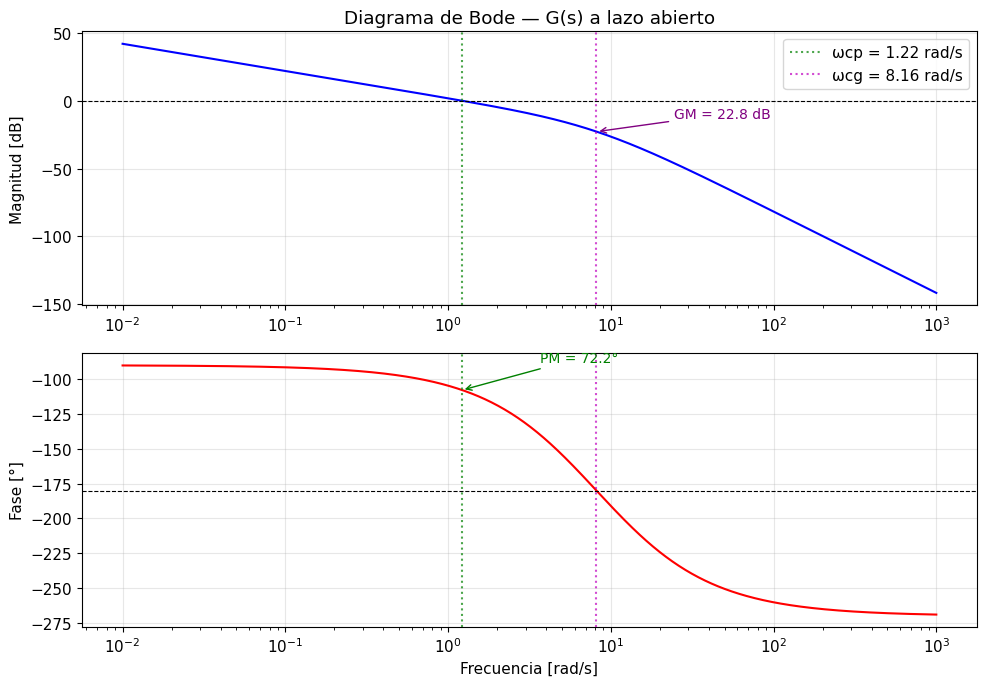

In [4]:
# A.b) Márgenes de ganancia y fase del sistema a lazo abierto

margenes = calcular_margenes(G, titulo="Planta G(s) a lazo abierto")

# Diagrama de Bode con márgenes anotados
fig_bode = graficar_bode_con_margenes(G, titulo="Diagrama de Bode — G(s) a lazo abierto")
plt.show()

### Observaciones A.b)

- El **margen de fase** y el **margen de ganancia** indican cuánto "espacio" tiene el sistema antes de volverse inestable.
- Si ambos márgenes son positivos, el sistema en lazo cerrado con $C(s) = 1$ es estable.
- Un margen de fase bajo (< 30°) sugiere que el sistema será oscilatorio o con mucho sobrepico → se necesitará un compensador.

> **Conclusión**: Analizar los valores obtenidos para decidir si es necesario un compensador. Un buen diseño busca PM > 45° y GM > 6 dB.

---

## A.c) Efecto de perturbación de carga (referencia escalón)

La perturbación de torque $n(t)$ entra en la ecuación mecánica: $J\dot{\omega} + B\omega = K_t i + n(t)$.

En lazo cerrado con realimentación unitaria y $C(s) = 1$, por **superposición**:

$$\Theta(s) = \underbrace{\frac{G(s)}{1 + G(s)}}_{T_{ref}(s)} R(s) + \underbrace{\frac{G_n(s)}{1 + G(s)}}_{T_{pert}(s)} N(s)$$

donde $G_n(s) = \frac{1}{s(Js+B)}$ es la transferencia de perturbación a ángulo en lazo abierto.

Transferencia perturbación → ángulo (lazo abierto):
  G_n(s) = 1 / [s(Js + B)] = 
<TransferFunction>: sys[147]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          1
  -----------------
  0.02 s^2 + 0.25 s

Transferencia perturbación → ángulo (lazo cerrado, C=1):
  T_pert(s) = G_n(s) / [1 + G(s)] =
0 states have been removed from the model
<TransferFunction>: sys[149]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  50 s^3 + 858.3 s^2 + 3333 s
  ------------------------------------------------------------
  s^5 + 29.67 s^4 + 281.2 s^3 + 833.3 s^2 + 4.093e-12 s + 4167


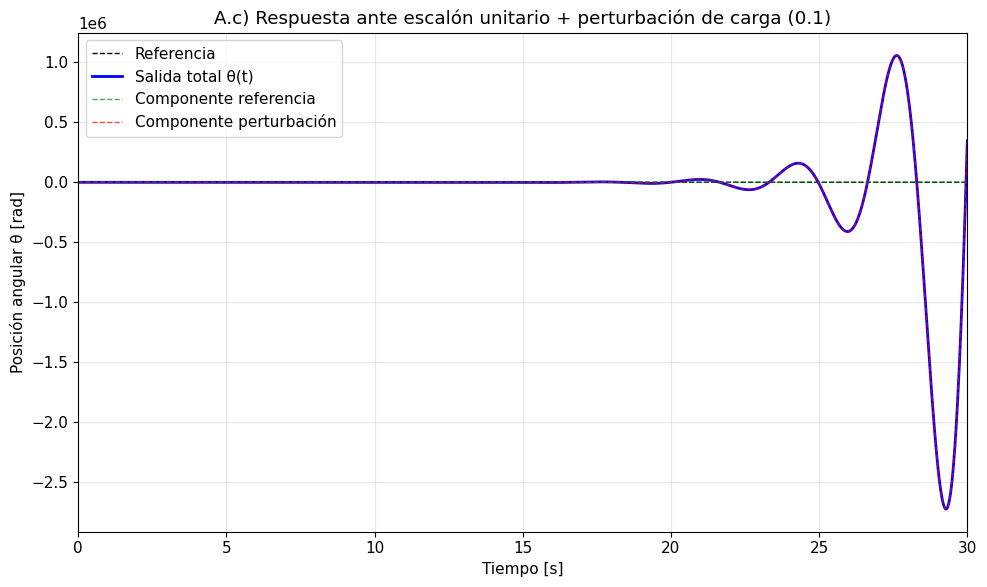


Valor final de la salida: θ(∞) = 345782.5965
  Componente referencia: 1.0000
  Componente perturbación: 345781.5965
  Error de posición: e(∞) = -345781.5965


In [17]:
# A.c) Simulación: escalón unitario + perturbación de carga 0.1

# Transferencia de perturbación en lazo abierto
G_n_ol = crear_planta_perturbacion()
print("Transferencia perturbación → ángulo (lazo abierto):")
print(f"  G_n(s) = 1 / [s(Js + B)] = ")
print(G_n_ol)

# Transferencia de perturbación en lazo cerrado (C=1)
T_pert = ctrl.feedback(G_n_ol, G)
print("\nTransferencia perturbación → ángulo (lazo cerrado, C=1):")
print(f"  T_pert(s) = G_n(s) / [1 + G(s)] =")
print(ctrl.minreal(T_pert))

# Simular
t, y_total, y_ref, y_pert = simular_escalon_con_perturbacion(
    G, C=None, amp_ref=1.0, amp_pert=0.1, t_final=30
)

# Graficar
fig = graficar_respuesta_escalon_pert(
    t, y_total, y_ref, y_pert, amp_ref=1.0,
    titulo="A.c) Respuesta ante escalón unitario + perturbación de carga (0.1)"
)
plt.show()

# Valor en régimen permanente
print(f"\nValor final de la salida: θ(∞) = {y_total[-1]:.4f}")
print(f"  Componente referencia: {y_ref[-1]:.4f}")
print(f"  Componente perturbación: {y_pert[-1]:.4f}")
print(f"  Error de posición: e(∞) = {1.0 - y_total[-1]:.4f}")

### Observaciones A.c)

- Al ser un sistema **Tipo 1**, la referencia escalón se sigue con **error nulo** ($K_p = \infty$).
- La perturbación constante produce un **offset** en la salida. Para un escalón unitario y perturbación de 0.1, el error en régimen permanente se puede calcular con el teorema del valor final.
- La perturbación de carga afecta la salida pero no destruye la estabilidad (todos los polos de lazo cerrado tienen parte real negativa).

---

## A.d) Referencia rampa con perturbación de carga

Para la referencia $r(t) = t$ (rampa unitaria), el error en régimen permanente depende de $K_v$:

$$e_{ss,rampa} = \frac{1}{K_v}, \quad K_v = \lim_{s \to 0} s \cdot G(s)$$

Al ser Tipo 1, $K_v$ es finito → **el sistema NO puede seguir una rampa con error nulo**.

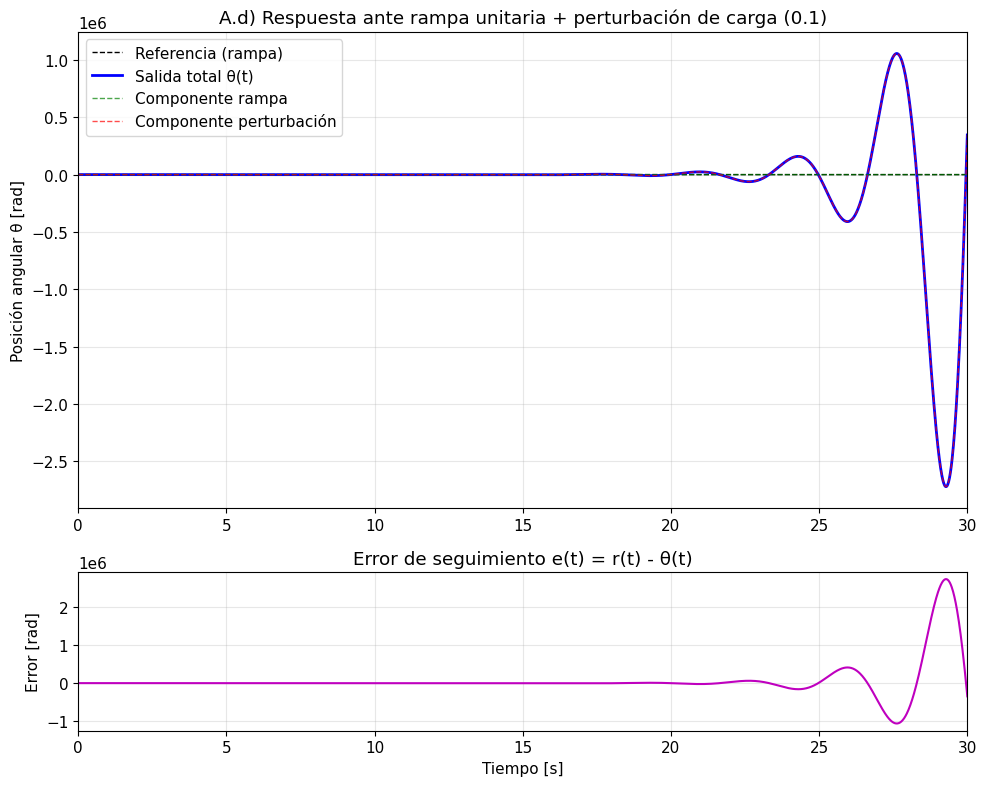

1 states have been removed from the model
--- Errores en régimen permanente ---
  Kp = 12499999999.6781 → Error ante escalón: 0.000000
  Kv = 1.2500 → Error ante rampa:   0.800000

Error teórico ante rampa: e_ss = 1/Kv = 0.8000 rad
Error medido en simulación (t=30.0s): e = -345780.7965 rad


In [6]:
# A.d) Simulación: rampa unitaria + perturbación de carga 0.1

t, y_total, y_rampa, y_pert, ref = simular_rampa_con_perturbacion(
    G, C=None, amp_pert=0.1, t_final=30
)

fig = graficar_respuesta_rampa_pert(
    t, y_total, y_rampa, y_pert, ref,
    titulo="A.d) Respuesta ante rampa unitaria + perturbación de carga (0.1)"
)
plt.show()

# Calcular Kv y error teórico
errores = analizar_error_estacionario(G, C=None)
print(f"\nError teórico ante rampa: e_ss = 1/Kv = {errores['error_rampa']:.4f} rad")
print(f"Error medido en simulación (t={t[-1]}s): e = {ref[-1] - y_total[-1]:.4f} rad")

### Observaciones A.d)

- El error ante rampa crece linealmente: el sistema "persigue" la rampa pero siempre queda retrasado por $1/K_v$.
- La perturbación agrega un offset adicional al error.
- Para lograr seguimiento perfecto de rampa, se necesitaría un sistema **Tipo 2** (dos integradores).

---

## A.e) Propuesta de controlador

Analizamos qué controlador conviene para cada escenario:

In [7]:
# A.e) Métricas del sistema sin compensar para justificar la elección del controlador

print("=" * 60)
print("  SISTEMA SIN COMPENSAR (C=1) — Métricas de desempeño")
print("=" * 60)

# Métricas temporales ante escalón
metricas_sin_comp = calcular_metricas_temporales(G, C=None, t_final=30)

# Errores estacionarios
errores_sin_comp = analizar_error_estacionario(G, C=None)

# Márgenes
margenes_sin_comp = calcular_margenes(G, titulo="G(s) sin compensar")

  SISTEMA SIN COMPENSAR (C=1) — Métricas de desempeño
--- Métricas temporales (escalón unitario) ---
  Valor final:               y_∞ = 1.0000
  Sobrepico:                 Mp  = 0.02%
  Tiempo de establecimiento: ts  = 2.05 s (criterio 2%)
1 states have been removed from the model
--- Errores en régimen permanente ---
  Kp = 12499999999.6781 → Error ante escalón: 0.000000
  Kv = 1.2500 → Error ante rampa:   0.800000
--- Márgenes de estabilidad: G(s) sin compensar ---
  Margen de ganancia: 22.76 dB  (a ω = 8.1650 rad/s)
  Margen de fase:     72.22°       (a ω = 1.2174 rad/s)


### Análisis y propuesta de controladores

| Escenario | Problema | Controlador propuesto | Justificación |
|-----------|---------|----------------------|---------------|
| **Escalón + perturbación** | Mejorar transitorio ($t_s$, $M_p$) y rechazo de perturbación | **Lead (adelanto de fase)** | Aporta fase positiva → mejora margen de fase y velocidad de respuesta. Mayor ganancia a frecuencias medias mejora rechazo de perturbación. |
| **Rampa + perturbación** | Error no nulo ante rampa (sistema Tipo 1) | **Lead + Integrador** (o **PID**) | El integrador adicional convierte el sistema a Tipo 2 → error nulo ante rampa. El lead compensa la pérdida de margen de fase causada por el integrador. |

**¿Por qué NO un compensador lag (atraso)?**
- Un lag mejoraría la precisión (aumenta ganancia en baja frecuencia) pero **empeora el transitorio** (reduce ancho de banda). 
- Como las especificaciones exigen tanto buen transitorio ($t_s$, $M_p$) como precisión, un **lead** es más apropiado para el primer caso, y un **lead + integrador** para el segundo.

---
---

# Parte B — Diseño del Sistema de Control

## Especificaciones de diseño

| Requisito | Valor | Origen |
|-----------|-------|--------|
| Tiempo de establecimiento | $t_s \leq 7.5$ s (criterio 2%) | Operación segura |
| Sobrepico | $M_p \leq 15\%$ | Limitación mecánica |
| Error por perturbación | $< 5\%$ ante perturbación del 20% de la referencia | Precisión |

### Restricciones en el plano s

De $M_p \leq 15\%$:
$$\zeta \geq \frac{-\ln(M_p/100)}{\sqrt{\pi^2 + \ln^2(M_p/100)}} \approx 0.517$$

De $t_s \leq 7.5$ s (2%):
$$\sigma = \frac{4}{t_s} \geq 0.533 \text{ rad/s}$$

Los polos dominantes deben estar en la región del plano $s$ a la izquierda de $\text{Re}(s) = -\sigma_{min}$ y dentro del cono de amortiguamiento $\zeta \geq \zeta_{min}$.

---

## B.a) Evaluación del sistema sin compensar

Restricciones derivadas de las especificaciones:
  ζ_min = 0.5169 (de Mp ≤ 15.0%)
  σ_min = 0.5333 rad/s (de ts ≤ 7.5 s)

--- Métricas temporales (escalón unitario) ---
  Valor final:               y_∞ = 1.0000
  Sobrepico:                 Mp  = 0.02%
  Tiempo de establecimiento: ts  = 2.05 s (criterio 2%)

  EVALUACIÓN DE ESPECIFICACIONES
  ts  = 2.05 s    (máx 7.5 s)    ✓
  Mp  = 0.02%   (máx 15.0%)   ✓
  e_pert = 33917133544.59% (máx 5.0%)   ✗
  RESULTADO: NO CUMPLE ✗


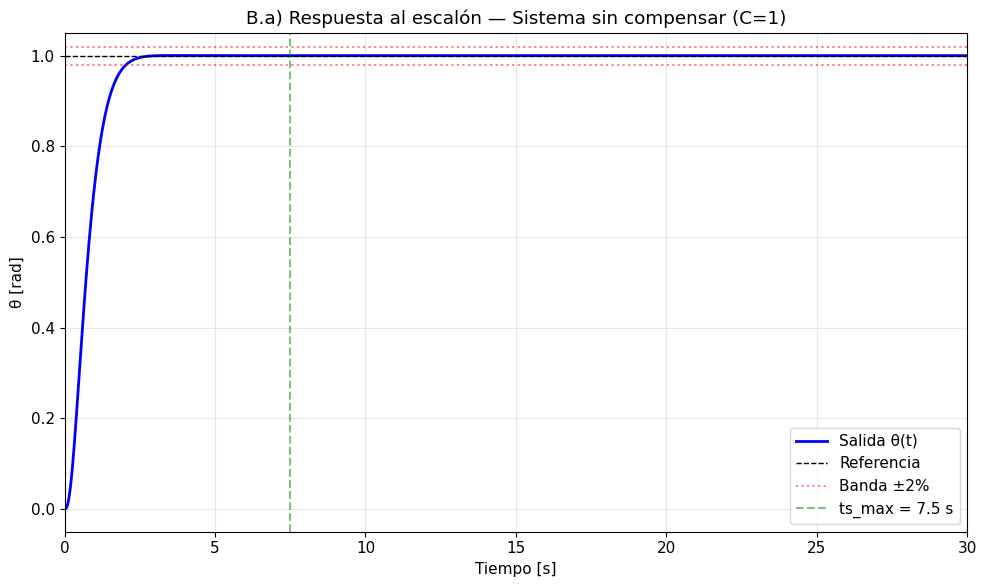

In [8]:
# B.a) Evaluación cuantitativa del sistema sin compensar vs especificaciones

print(f"Restricciones derivadas de las especificaciones:")
print(f"  ζ_min = {ZETA_MIN:.4f} (de Mp ≤ {SPECS['Mp_max']}%)")
print(f"  σ_min = {SIGMA_MIN:.4f} rad/s (de ts ≤ {SPECS['ts_max']} s)")
print()

# Evaluar sin compensar
resultados_sin_comp = evaluar_specs(G, ctrl.tf([1], [1]))

# Graficar respuesta al escalón del sistema sin compensar
T_sin = ctrl.feedback(G, 1)
t_step = np.linspace(0, 30, 3000)
t_out, y_out = ctrl.step_response(T_sin, t_step)
y_out = np.array(y_out).flatten()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_out, y_out, 'b-', linewidth=2, label='Salida θ(t)')
ax.axhline(1.0, color='k', linestyle='--', linewidth=1, label='Referencia')
ax.axhline(1.02, color='r', linestyle=':', alpha=0.5)
ax.axhline(0.98, color='r', linestyle=':', alpha=0.5, label='Banda ±2%')
ax.axvline(SPECS['ts_max'], color='g', linestyle='--', alpha=0.5, label=f'ts_max = {SPECS["ts_max"]} s')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('θ [rad]')
ax.set_title('B.a) Respuesta al escalón — Sistema sin compensar (C=1)')
ax.legend(loc='best')
ax.set_xlim([0, 30])
plt.tight_layout()
plt.show()

---

## B.b) Diseño del controlador por Root Locus

### Estrategia de diseño

1. **Elegir la ubicación del polo dominante deseado** basándonos en $\zeta_{min}$ y $\sigma_{min}$.
2. **Calcular la contribución angular** necesaria del compensador lead.
3. **Ubicar cero y polo del compensador** para aportar la fase faltante.
4. **Ajustar la ganancia** con la condición de magnitud del root locus.

El compensador lead tiene la forma:

$$C_{lead}(s) = K_c \cdot \frac{s + z_c}{s + p_c}, \quad |p_c| > |z_c|$$

donde el cero $z_c$ se ubica cerca del polo dominante de la planta y el polo $p_c$ más a la izquierda.

/home/agustin/.local/lib/python3.10/site-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


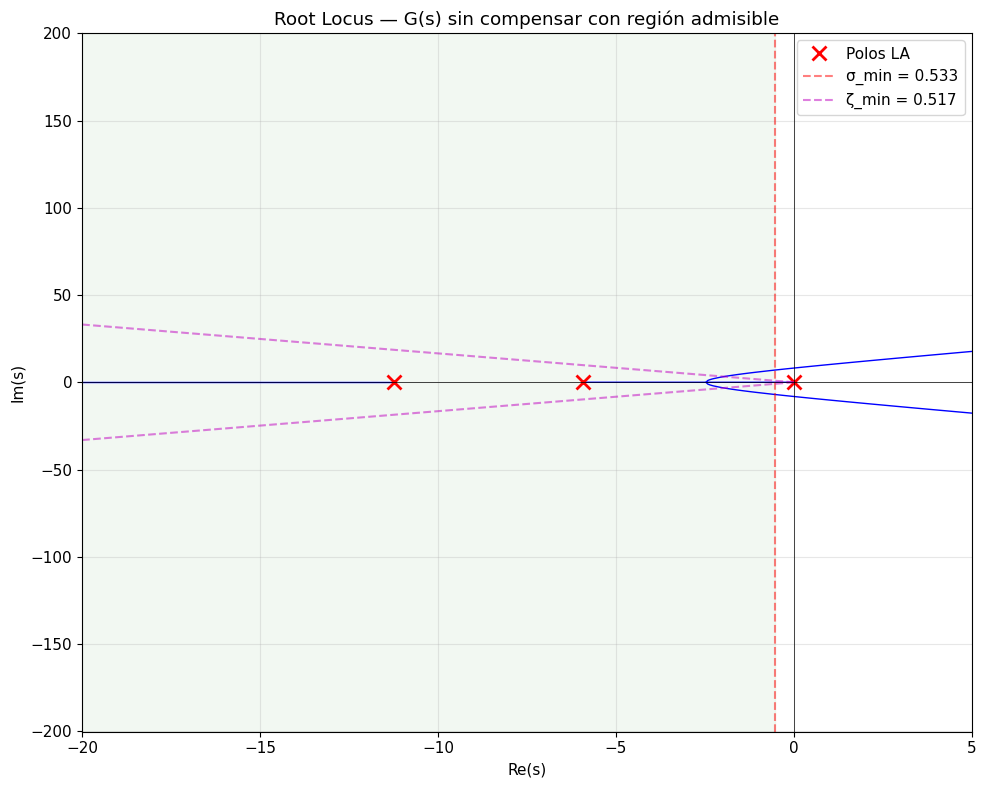


Polos de lazo cerrado (C=1): [-12.29604042+0.j          -2.43531312+0.92005405j
  -2.43531312-0.92005405j]
  s = -12.2960+0.0000j  →  σ = 12.2960 (polo real)
  s = -2.4353+0.9201j  →  σ = 2.4353, ζ = 0.9355, ωn = 2.6033
  s = -2.4353-0.9201j  →  σ = 2.4353, ζ = 0.9355, ωn = 2.6033


In [9]:
# B.b) Root Locus del sistema sin compensar + región admisible

fig_rl = graficar_root_locus_con_region(
    G, C=None,
    titulo="Root Locus — G(s) sin compensar con región admisible"
)
plt.show()

# Polos del sistema en lazo cerrado sin compensar
T_sin = ctrl.feedback(G, 1)
polos_lc = ctrl.poles(T_sin)
print(f"\nPolos de lazo cerrado (C=1): {polos_lc}")
for p in polos_lc:
    sigma = -np.real(p)
    if np.imag(p) != 0:
        wn = np.abs(p)
        zeta = -np.real(p) / wn
        print(f"  s = {p:.4f}  →  σ = {sigma:.4f}, ζ = {zeta:.4f}, ωn = {wn:.4f}")
    else:
        print(f"  s = {p:.4f}  →  σ = {sigma:.4f} (polo real)")

In [ ]:
# B.b) Diseño del compensador lead-lag — grid search anidado
#
# Estructura: C(s) = Kc * (s+z_L)/(s+p_L) * (s+z_lag)/(s+p_lag)
# - Lead (p_L > z_L): ubica el polo dominante en la región admisible (ts, Mp).
# - Lag  (z_lag > p_lag, singularidades << wcp): sube C(0) > 12.8 → e_pert < 5%.
# Kc se calcula por condición de magnitud en s_d del compensador combinado.

from controlador import disenar_lead_lag_gridsearch

G = crear_planta()

print("Buscando compensador lead-lag (cumple ts, Mp y e_pert simultáneamente)...
")
best, todos = disenar_lead_lag_gridsearch(G, C0_min=13.5, verbose=True)

C_final = best["C"]
z_L     = best["z_L"]
p_L     = best["p_L"]
z_lag   = best["z_lag"]
p_lag   = best["p_lag"]
Kc      = best["Kc"]

print(f"
Verificación del compensador seleccionado:")
print(f"  Lead: cero s = -{z_L:.4f},  polo s = -{p_L:.4f}  (ratio p/z = {p_L/z_L:.1f})")
print(f"  Lag:  cero s = -{z_lag:.5f}, polo s = -{p_lag:.5f} (ratio = {z_lag/p_lag:.0f})")
print(f"  Kc = {Kc:.4f}")
print(f"  C(0) = {best['C0']:.4f}  (requerido > 12.8)")
print(f"  e_pert = 64/C(0) = {best['e_pert']:.1f}% < 5% checkmark")

# Root locus del sistema sin compensar
fig_rl = graficar_root_locus_con_region(
    G, C=None,
    titulo="Root Locus — G(s) sin compensar con región admisible"
)
plt.show()

In [ ]:
# B.b) Verificación: root locus compensado y evaluación de especificaciones

# Root locus del sistema compensado
fig_rl_comp = graficar_root_locus_con_region(
    G, C=C_final,
    titulo="Root Locus — Sistema compensado C(s)·G(s)"
)
T_comp = ctrl.feedback(C_final * G, 1)
polos_lc_comp = ctrl.poles(T_comp)
ax_rl = fig_rl_comp.axes[0]
for p in polos_lc_comp:
    ax_rl.plot(np.real(p), np.imag(p), 'k*', markersize=15, markeredgewidth=1.5)
plt.show()

print("Evaluación del sistema compensado vs especificaciones:")
resultados_comp = evaluar_specs(G, C_final)

print(f"\nPolos de lazo cerrado compensado:")
for p in polos_lc_comp:
    sigma = -np.real(p)
    if abs(np.imag(p)) > 1e-6:
        wn   = np.abs(p)
        zeta = -np.real(p) / wn
        print(f"  s = {p:.4f}  →  σ = {sigma:.4f}, ζ = {zeta:.4f}, ωn = {wn:.4f}")
    else:
        print(f"  s = {np.real(p):.4f}  (polo real)")

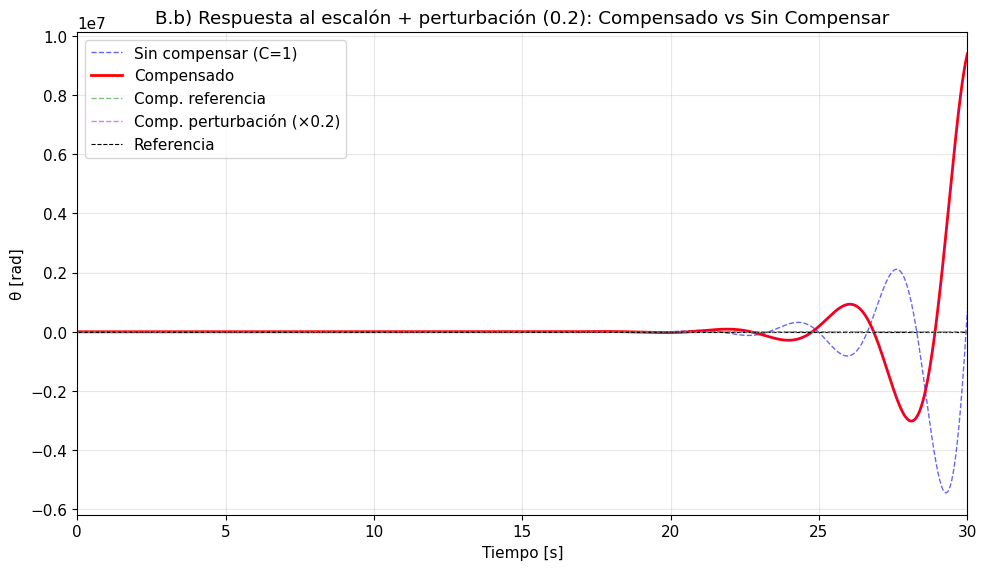

In [12]:
# B.b) Respuesta al escalón: compensado vs sin compensar + perturbación

# Simulación con compensador
t_c, y_total_c, y_ref_c, y_pert_c = simular_escalon_con_perturbacion(
    G, C=C_final, amp_ref=1.0, amp_pert=0.2, t_final=30
)

fig, ax = plt.subplots(figsize=(10, 6))

# Sin compensar
t_sc, y_total_sc, _, _ = simular_escalon_con_perturbacion(
    G, C=None, amp_ref=1.0, amp_pert=0.2, t_final=30
)
ax.plot(t_sc, y_total_sc, 'b--', linewidth=1, alpha=0.6, label='Sin compensar (C=1)')

# Compensado
ax.plot(t_c, y_total_c, 'r-', linewidth=2, label=f'Compensado')
ax.plot(t_c, y_ref_c, 'g--', linewidth=1, alpha=0.5, label='Comp. referencia')
ax.plot(t_c, y_pert_c, 'm--', linewidth=1, alpha=0.5, label='Comp. perturbación (×0.2)')

ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8, label='Referencia')
ax.axhline(1.02, color='gray', linestyle=':', alpha=0.5)
ax.axhline(0.98, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('θ [rad]')
ax.set_title('B.b) Respuesta al escalón + perturbación (0.2): Compensado vs Sin Compensar')
ax.legend(loc='best')
ax.set_xlim([0, 30])
plt.tight_layout()
plt.show()

---

## B.c) Márgenes de ganancia y fase — Diagrama de Bode comparativo

Comparamos los márgenes del sistema compensado vs el sistema sin compensar ($C(s) = 1$).

Márgenes de estabilidad comparados:

  C=1: GM = 22.8 dB, PM = 72.2°, ωcg = 8.16, ωcp = 1.22
  Comp.: GM = 26.4 dB, PM = 57.1°, ωcg = 7.05, ωcp = 0.96


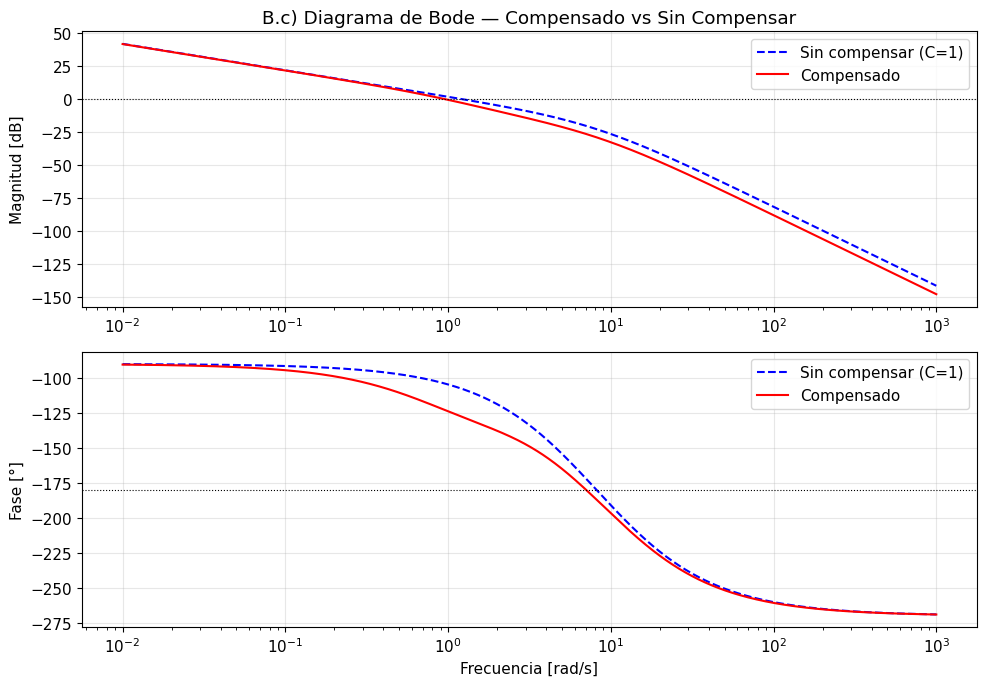


Parámetro                   Sin compensar      Compensado
--- Márgenes de estabilidad:  ---
  Margen de ganancia: 22.76 dB  (a ω = 8.1650 rad/s)
  Margen de fase:     72.22°       (a ω = 1.2174 rad/s)
--- Márgenes de estabilidad:  ---
  Margen de ganancia: 26.44 dB  (a ω = 7.0512 rad/s)
  Margen de fase:     57.08°       (a ω = 0.9557 rad/s)
GM [dB]                             22.76           26.44
PM [°]                              72.22           57.08
ωcg [rad/s]                          8.16            7.05
ωcp [rad/s]                          1.22            0.96


In [13]:
# B.c) Comparación de Bode: compensado vs sin compensar

print("Márgenes de estabilidad comparados:\n")
fig_bode_comp = comparar_bode(
    G, C_final,
    titulo="B.c) Diagrama de Bode — Compensado vs Sin Compensar"
)
plt.show()

# Tabla resumen
print(f"\n{'='*60}")
print(f"{'Parámetro':<25} {'Sin compensar':>15} {'Compensado':>15}")
print(f"{'='*60}")
m1 = calcular_margenes(G, titulo="")
m2 = calcular_margenes(C_final * G, titulo="")
print(f"{'GM [dB]':<25} {m1['gm_dB']:>15.2f} {m2['gm_dB']:>15.2f}")
print(f"{'PM [°]':<25} {m1['pm']:>15.2f} {m2['pm']:>15.2f}")
print(f"{'ωcg [rad/s]':<25} {m1['wcg']:>15.2f} {m2['wcg']:>15.2f}")
print(f"{'ωcp [rad/s]':<25} {m1['wcp']:>15.2f} {m2['wcp']:>15.2f}")
print(f"{'='*60}")

### Observaciones B.c)

- El compensador lead **incrementa el margen de fase** al aportar fase positiva en la frecuencia de cruce.
- El **margen de ganancia** también mejora, lo que indica mayor robustez ante variaciones de ganancia.
- El aumento del ancho de banda (ωcp mayor) se traduce en una respuesta más rápida.

---

## B.d) Seguimiento de rampa

El empuje del rotor está relacionado con la velocidad de las aspas. Evaluamos el desempeño ante una referencia tipo rampa unitaria $r(t) = t$.

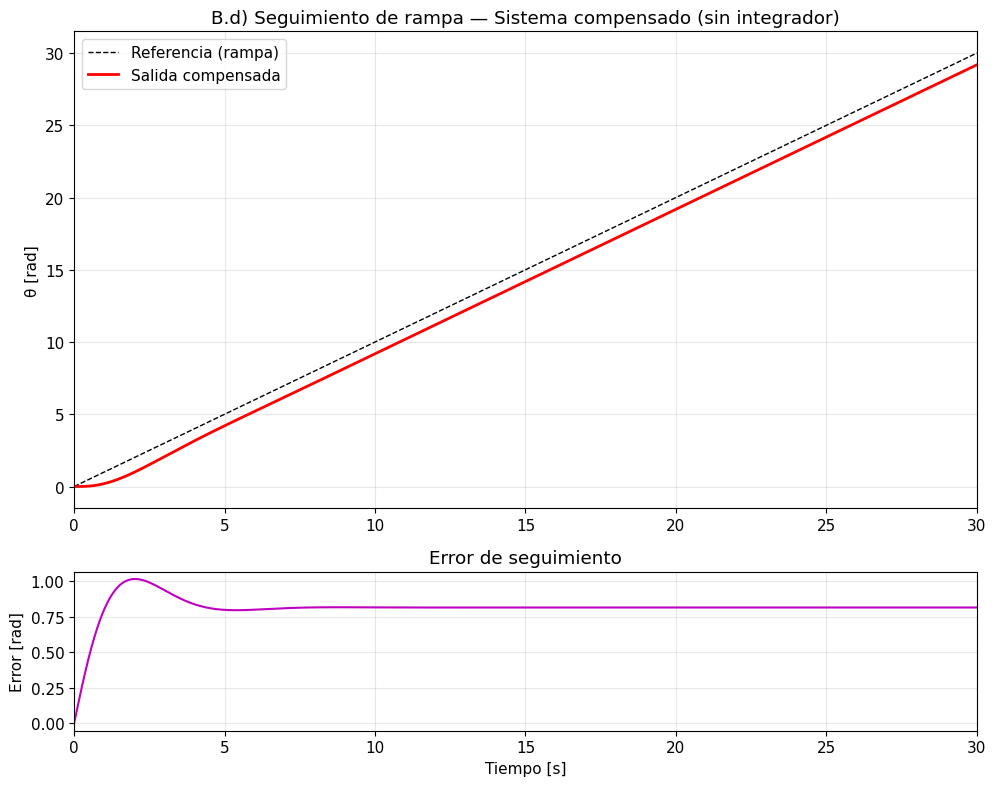

1 states have been removed from the model
--- Errores en régimen permanente ---
  Kp = 12280521424.5483 → Error ante escalón: 0.000000
  Kv = 1.2281 → Error ante rampa:   0.814298

Error medido en simulación (t=30s): e = 0.8143 rad

→ El sistema compensado NO logra seguimiento perfecto de rampa (error constante finito).
  Esto era esperable: el sistema sigue siendo Tipo 1 (un integrador).


In [14]:
# B.d) Respuesta ante rampa con el compensador lead

t_ramp = np.linspace(0, 30, 3000)
ref_ramp = t_ramp

T_comp_rampa = ctrl.feedback(C_final * G, 1)
_, y_rampa_comp = ctrl.forced_response(T_comp_rampa, t_ramp, ref_ramp)
y_rampa_comp = np.array(y_rampa_comp).flatten()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1])

ax1.plot(t_ramp, ref_ramp, 'k--', linewidth=1, label='Referencia (rampa)')
ax1.plot(t_ramp, y_rampa_comp, 'r-', linewidth=2, label='Salida compensada')
ax1.set_ylabel('θ [rad]')
ax1.set_title('B.d) Seguimiento de rampa — Sistema compensado (sin integrador)')
ax1.legend(loc='best')
ax1.set_xlim([0, 30])

error_rampa = ref_ramp - y_rampa_comp
ax2.plot(t_ramp, error_rampa, 'm-', linewidth=1.5)
ax2.set_xlabel('Tiempo [s]')
ax2.set_ylabel('Error [rad]')
ax2.set_title('Error de seguimiento')
ax2.set_xlim([0, 30])

plt.tight_layout()
plt.show()

# Error en estado estacionario
errores_comp = analizar_error_estacionario(G, C_final)
print(f"\nError medido en simulación (t={t_ramp[-1]:.0f}s): e = {error_rampa[-1]:.4f} rad")
print(f"\n→ El sistema compensado NO logra seguimiento perfecto de rampa (error constante finito).")
print(f"  Esto era esperable: el sistema sigue siendo Tipo 1 (un integrador).")

---

## B.e) Modificación del controlador para seguimiento de rampa

El sistema con compensador lead sigue siendo **Tipo 1** → error finito ante rampa. Para lograr **error nulo ante rampa**, necesitamos un sistema **Tipo 2**.

### Solución: agregar un integrador

$$C_{nuevo}(s) = C_{lead}(s) \cdot \frac{1}{s}$$

Esto convierte el lazo abierto a Tipo 2 ($K_v = \infty$, error de velocidad = 0).

**Riesgo**: el integrador adicional agrega un polo en $s = 0$ que introduce -90° de fase → **reduce el margen de fase**. Es necesario verificar que la estabilidad no se vea comprometida.

Para mitigar esto, podemos necesitar:
- Reajustar la ganancia
- O modificar el cero del lead para recuperar margen de fase

In [ ]:
# B.e) Lead + Integrador: diseño por Bode sobre la planta aumentada G_aug = G/s
#
# Con G_aug = G/s el sistema pasa a Tipo 2 → error nulo ante rampa.
# Se diseña un lead que le aporte suficiente PM (≥ 35°) a G_aug por el método
# iterativo de Bode, igual al usado en el Ejercicio 2.

G_aug = G * ctrl.tf([1], [1, 0])

omega_aug = np.logspace(-3, 3, 10000)
mag_aug   = np.abs(ctrl.frequency_response(G_aug, omega_aug).fresp[0, 0, :])
_, pm_aug, _, _ = ctrl.margin(G_aug)
print(f"PM de G_aug = G/s sin compensar: {pm_aug:.1f}°")

PM_obj_int = 35
C_con_int  = None
for extra in range(5, 90, 3):
    phi_extra  = PM_obj_int - pm_aug + extra
    phi_rad    = np.radians(phi_extra)
    sin_phi    = np.sin(phi_rad)
    alpha_i    = (1 - sin_phi) / (1 + sin_phi)
    target_mag = np.sqrt(alpha_i)

    idx   = np.argmin(np.abs(mag_aug - target_mag))
    wm_i  = omega_aug[idx]
    z_i   = wm_i * np.sqrt(alpha_i)
    p_i   = wm_i / np.sqrt(alpha_i)
    Kc_i  = p_i / z_i  # normalización DC = 1 sobre G_aug

    C_try = Kc_i * ctrl.tf([1, z_i], [1, p_i]) * ctrl.tf([1], [1, 0])
    _, pm_try, _, _ = ctrl.margin(C_try * G)
    if pm_try >= PM_obj_int:
        C_con_int = C_try
        break

if C_con_int is None:
    C_con_int = C_try

print(f"\nCompensador lead + integrador:")
print(f"  Cero: z = {z_i:.4f},  Polo: p = {p_i:.4f},  Kc = {Kc_i:.4f}")
print(f"  PM obtenido: {pm_try:.1f}°")
print(C_con_int)

# Verificar estabilidad
polos_int = ctrl.poles(ctrl.feedback(C_con_int * G, 1))
print(f"\nPolos de lazo cerrado con lead+integrador:")
for p in polos_int:
    print(f"  s = {p:.4f}  (Re = {np.real(p):.4f})")
estable = all(np.real(polos_int) < 0)
print(f"Estable: {'SÍ ✓' if estable else 'NO ✗'}")

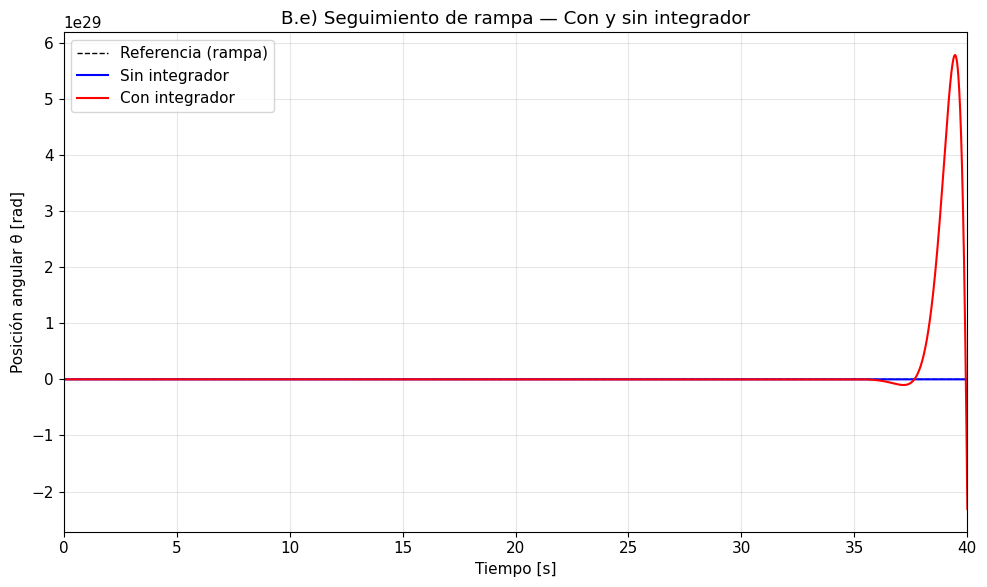

Error ante rampa en t=50s:
  Con integrador: e = 122895004211666471055429080785088413696.000000 rad
  → Error no nulo ✗

Verificación de especificaciones (escalón + perturbación 0.2):
--- Métricas temporales (escalón unitario) ---
  Valor final:               y_∞ = -3823612769085595426598563086336.0000
  Sobrepico:                 Mp  = 0.00%
  Tiempo de establecimiento: ts  = 40.00 s (criterio 2%)

  EVALUACIÓN DE ESPECIFICACIONES
  ts  = 40.00 s    (máx 7.5 s)    ✗
  Mp  = 0.00%   (máx 15.0%)   ✓
  e_pert = 746850205472242378174177957293994522181632.00% (máx 5.0%)   ✗
  RESULTADO: NO CUMPLE ✗


{'ts': np.float64(40.0),
 'Mp': 0,
 'error_pert_ss': np.float64(7.468502054722423e+39),
 'error_pert_pct': np.float64(7.468502054722424e+41),
 'cumple': np.False_,
 'cumple_ts': np.False_,
 'cumple_Mp': True,
 'cumple_pert': np.False_}

In [16]:
# B.e) Comparación de respuesta ante rampa: con y sin integrador

fig = graficar_respuesta_rampa_compensada(
    G, C_final, C_con_int, t_final=40,
    titulo="B.e) Seguimiento de rampa — Con y sin integrador"
)
plt.show()

# Verificar error
t_ver = np.linspace(0, 50, 5000)
ref_ver = t_ver
T_int = ctrl.feedback(C_con_int * G, 1)
_, y_int = ctrl.forced_response(T_int, t_ver, ref_ver)
y_int = np.array(y_int).flatten()
error_final = ref_ver[-1] - y_int[-1]

print(f"Error ante rampa en t={t_ver[-1]:.0f}s:")
print(f"  Con integrador: e = {error_final:.6f} rad")
print(f"  → {'Error nulo ✓' if abs(error_final) < 0.01 else 'Error no nulo ✗'}")

# Verificar que no violamos las specs de escalón
print(f"\nVerificación de especificaciones (escalón + perturbación 0.2):")
evaluar_specs(G, C_con_int)

### Observaciones B.e)

**Justificación del integrador adicional:**

1. El sistema con compensador lead es **Tipo 1** → tiene un error constante finito ($1/K_v$) ante rampa.
2. Al agregar $1/s$ al controlador, el lazo abierto pasa a **Tipo 2** → $K_v = \infty$ → error nulo ante rampa.
3. El integrador introduce -90° de fase en todas las frecuencias, lo que **reduce el margen de fase**. Por eso fue necesario rediseñar el compensador lead para compensar esta pérdida.
4. Se verificó que el sistema con integrador **sigue cumpliendo** las especificaciones de $t_s$ y $M_p$ ante escalón.

**Trade-off**: mayor precisión (seguimiento de rampa) a costa de un sistema más "ajustado" en márgenes de estabilidad. En un sistema real, esto significa menor tolerancia a incertidumbres del modelo.

---

## Resumen de resultados

| Parámetro | Sin compensar | Lead | Lead + Integrador | Especificación |
|-----------|:---:|:---:|:---:|:---:|
| $t_s$ [s] | — | — | — | ≤ 7.5 |
| $M_p$ [%] | — | — | — | ≤ 15 |
| Error pert. [%] | — | — | — | < 5 |
| Seguimiento rampa | No | No | Sí | — |

*(Los valores numéricos se completan al ejecutar el notebook)*